In [89]:
# Importaciones
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.Routes import RUTAS

print('Claves disponibles en RUTAS:', list(RUTAS.keys()))

Claves disponibles en RUTAS: ['data', 'notebooks', 'data_processed', 'data_raw', 'figures', 'imagenes']


In [90]:
df_limpio= pd.read_excel(RUTAS['data_processed'] / 'Sales_Marketing_Clean.xlsx')

columnas_finales = df_limpio.columns

df_limpio.head()

,age,total_spent,avg_order_value,lifetime_value,last_3_month_purchase_freq,marketing_spend_per_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,support_tickets,delivery_delay_days,satisfaction_score,nps_score,gender,country,acquisition_channel,subscription_type,payment_method
0,35,559.525,65.247,915.311,14,27.559999,7,13.904,5.415,0.67,0.26,0,3,3,10,Male,India,Email,Annual,Upi
1,35,356.491,48.474,2079.961,11,15.150000,19,5.113,5.352,0.70,0.37,5,3,3,7,Unknown,Germany,Organic,Monthly,Bkash
2,27,689.332,77.815,1379.151,9,13.510000,18,9.743,3.595,0.47,0.44,1,2,5,6,Female,Germany,Email,Annual,Upi
3,36,445.430,71.712,774.653,7,25.650000,16,9.643,2.950,0.58,0.37,0,2,4,6,Female,India,Facebook Ads,Annual,Paypal
4,29,686.286,44.990,87.680,11,12.390000,12,7.791,2.406,0.05,0.16,2,4,3,1,Male,USA,Referral,Monthly,Bkash


In [91]:
df_sucio= pd.read_excel(RUTAS['data_raw'] / 'Dirty_Sales_Marketing_Dataset.xlsx')

df_sucio =df_sucio[columnas_finales]

df_sucio.head()

,age,total_spent,avg_order_value,lifetime_value,last_3_month_purchase_freq,marketing_spend_per_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,support_tickets,delivery_delay_days,satisfaction_score,nps_score,gender,country,acquisition_channel,subscription_type,payment_method
0,nan,559.524958,65.246704,915.310827,14,27.56,7,13.903745,5.415164,0.67,0.26,0,3,3.0,10,MALE,India,Email,Annual,UPI
1,35.0,356.491344,48.473887,2079.960938,11,15.15,19,5.112528,5.352441,0.70,0.37,5,3,3.0,7,nan,Germany,Organic,Monthly,BKash
2,27.0,689.332196,77.815371,1379.150885,9,13.51,18,9.742749,3.594719,0.47,0.44,1,2,5.0,6,female,Germany,Email,Annual,UPI
3,36.0,445.429636,71.712192,774.652684,7,25.65,16,9.642654,2.949531,0.58,0.37,0,2,4.0,6,FEMALE,India,Facebook Ads,Annual,PayPal
4,29.0,686.286022,44.990246,87.680409,11,12.39,12,7.791291,2.405539,0.05,0.16,2,4,3.0,1,MALE,USA,Referral,Monthly,BKash


In [93]:
nulos_df_sucio = df_sucio.isnull().sum()
nulos_df_limpio = df_limpio.isnull().sum()

In [94]:
tabla_comparativa = pd.DataFrame({'df original': nulos_df_sucio, 'df limpio': nulos_df_limpio})

tabla_comparativa

,df original,df limpio
age,0,0
total_spent,1110,0
avg_order_value,0,0
lifetime_value,0,0
last_3_month_purchase_freq,0,0
marketing_spend_per_user,0,0
total_visits,0,0
avg_session_time,0,0
pages_per_session,0,0
email_open_rate,0,0


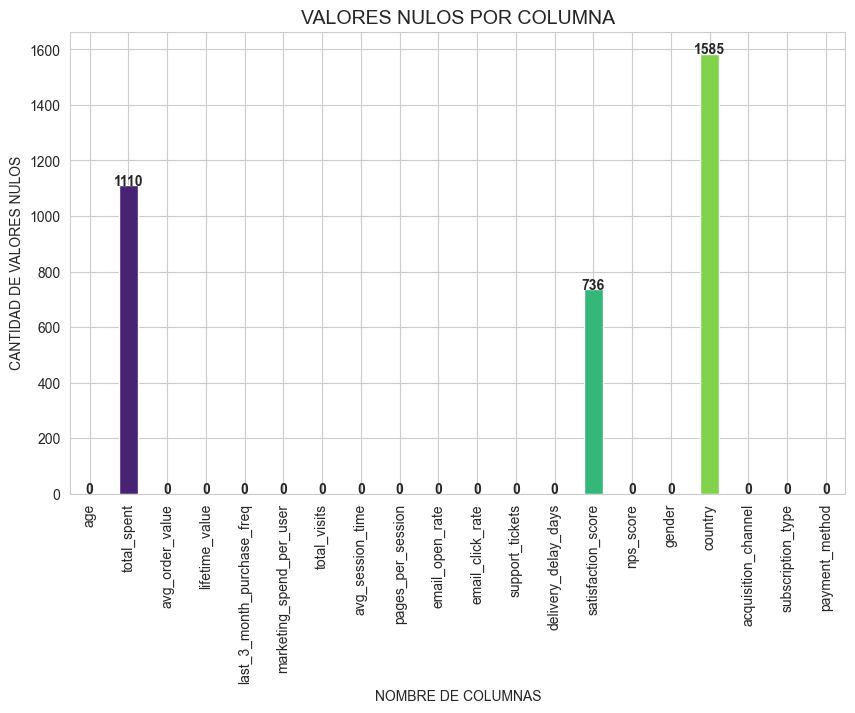

In [ ]:

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = nulos_df_sucio.plot(kind='bar', color=sns.color_palette('viridis', len(nulos_df_sucio)))

plt.title('VALORES NULOS POR COLUMNA', fontsize=14)
plt.ylabel('CANTIDAD DE VALORES NULOS')
plt.xlabel('NOMBRE DE COLUMNAS')
plt.xticks(rotation=90)

# Añadimos el número exacto encima de cada barra
for indice, valor in enumerate(nulos_df_sucio):
    ax.text(indice, valor + 0.1, str(valor), ha='center', fontweight='bold')

plt.savefig(RUTAS['figures'] / 'conteo_nulos_bar.png')



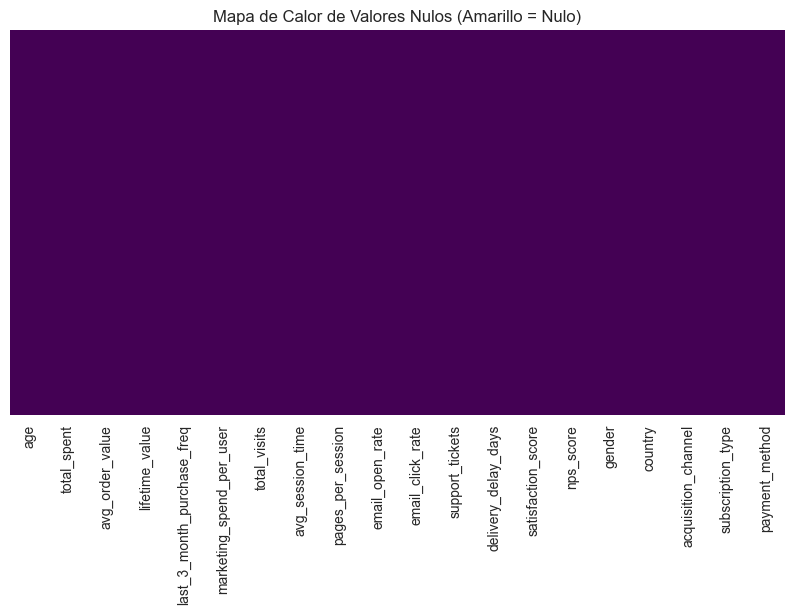

<Figure size 640x480 with 0 Axes>

In [96]:
plt.figure(figsize=(10, 5))
# df.isnull() crea una matriz de True/False, el heatmap la visualiza
sns.heatmap(df_limpio.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Mapa de Calor de Valores Nulos (Amarillo = Nulo)')
plt.show()
plt.savefig(RUTAS['figures'] / 'heatmap_nulos.png')

- Al validar el dataframe limpio, se observa que no hay valores nulos, lo que confirma que el proceso de limpieza fue exitoso. Esto es crucial para garantizar la calidad de los análisis posteriores y la confiabilidad de los resultados obtenidos a partir de este conjunto de datos.


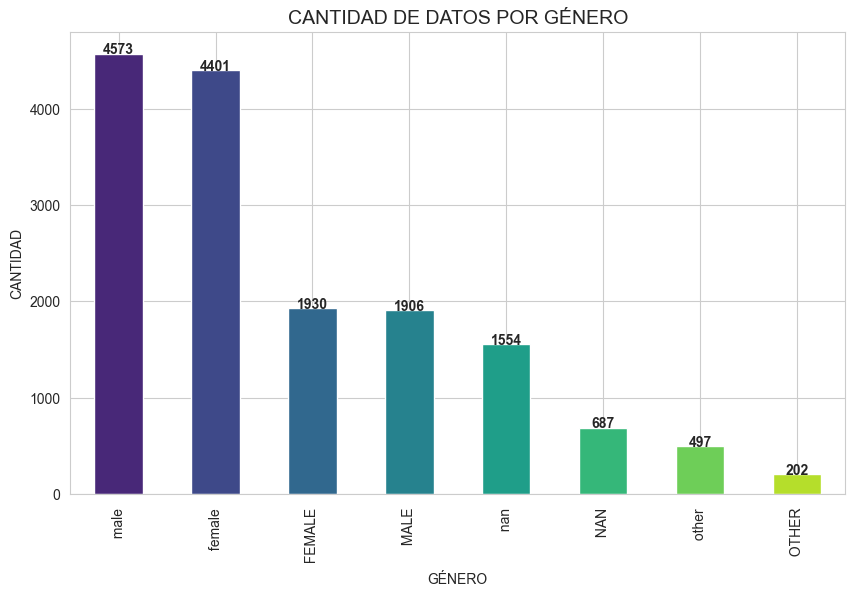

In [97]:
# Comparacion de normalizacion de variables categoricas

generos_sucio = df_sucio['gender'].value_counts()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = generos_sucio.plot(kind='bar', color=sns.color_palette('viridis', len(generos_sucio)))

plt.title('CANTIDAD DE DATOS POR GÉNERO', fontsize=14)
plt.ylabel('CANTIDAD')
plt.xlabel('GÉNERO')
plt.xticks(rotation=90)

# Añadimos el número exacto encima de cada barra
for indice, valor in enumerate(generos_sucio):
    ax.text(indice, valor + 0.1, str(valor), ha='center', fontweight='bold')

plt.savefig(RUTAS['figures'] / 'conteo_generos_sucios_bar.png')

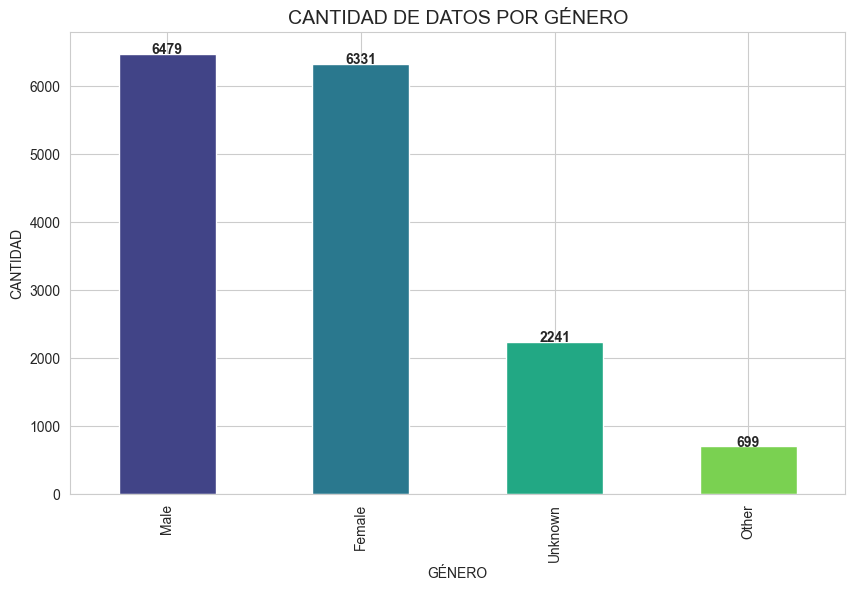

In [98]:
# Comparacion de normalizacion de variables categoricas

generos_limpio = df_limpio['gender'].value_counts()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = generos_limpio.plot(kind='bar', color=sns.color_palette('viridis', len(generos_limpio)))

plt.title('CANTIDAD DE DATOS POR GÉNERO', fontsize=14)
plt.ylabel('CANTIDAD')
plt.xlabel('GÉNERO')
plt.xticks(rotation=90)

# Añadimos el número exacto encima de cada barra
for indice, valor in enumerate(generos_limpio):
    ax.text(indice, valor + 0.1, str(valor), ha='center', fontweight='bold')

plt.savefig(RUTAS['figures'] / 'conteo_generos_limpios_bar.png')

- Al validar la cantidad de datos por genero podemos observar que el proceso de limpieza y normalización ha unificado los valores de género, eliminando inconsistencias como espacios, Mayusculas y minusculas mezcladas


In [ ]:
# Validacion de Outliers

columnas_outliers = [
    'age', 'total_spent', 'avg_order_value', 'lifetime_value',
    'total_visits', 'avg_session_time', 'pages_per_session',
    'support_tickets', 'delivery_delay_days'
]
minimos = []
maximos = []
promedios = []
for columna in columnas_outliers:
    df_sucio[columna] = pd.to_numeric(df_sucio[columna], errors='coerce')
    minimo = df_sucio[columna].min()
    maximo = df_sucio[columna].max()
    promedio = df_sucio[columna].mean()
    minimos.append(minimo)
    maximos.append(maximo)
    promedios.append(promedio)

df_outliers_sucio = pd.DataFrame({
    'Variable': columnas_outliers,
    'Mínimo': minimos,
    'Máximo': maximos,
    'Promedio': promedios
})


In [ ]:
# Validacion de Outliers

columnas_outliers = [
    'age', 'total_spent', 'avg_order_value', 'lifetime_value',
    'total_visits', 'avg_session_time', 'pages_per_session',
    'support_tickets', 'delivery_delay_days'
]
minimos = []
maximos = []
promedios = []
for columna in columnas_outliers:
    minimo = df_limpio[columna].min()
    maximo = df_limpio[columna].max()
    promedio = df_limpio[columna].mean()
    minimos.append(minimo)
    maximos.append(maximo)
    promedios.append(promedio)

df_outliers_limpio = pd.DataFrame({
    'Variable': columnas_outliers,
    'Mínimo': minimos,
    'Máximo': maximos,
    'Promedio': promedios
})

In [ ]:

df_comparativo_outliers = df_outliers_sucio.merge(df_outliers_limpio, on='Variable', suffixes=('_Sucio', '_Limpio'))
df_comparativo_outliers

,Variable,Mínimo_Sucio,Máximo_Sucio,Promedio_Sucio,Mínimo_Limpio,Máximo_Limpio,Promedio_Limpio
0,age,-4.000000,3520.391304,119.104024,14.000,58.000,35.584571
1,total_spent,0.267291,15910.431879,524.036282,0.267,1231.482,509.300749
2,avg_order_value,0.071596,154.554696,60.084236,0.072,127.634,60.053886
3,lifetime_value,0.368886,3767.490455,1234.659465,0.369,3082.785,1233.926813
4,total_visits,3.000000,31.000000,14.996635,3.000,27.000,14.992254
5,avg_session_time,0.006095,19.123716,8.021602,0.006,16.173,8.019517
6,pages_per_session,0.007845,10.843172,3.999655,0.008,8.046,3.998566
7,support_tickets,0.000000,9.000000,1.997778,0.000,6.000,1.991175
8,delivery_delay_days,0.000000,11.000000,2.986540,0.000,7.000,2.969270


- Al hacer la compararción del dataset original vs el dataset limpio, se puede observar que el dataset limpio tiene valores mínimos y máximos más razonables en comparación con el dataset original, lo que sugiere que se han eliminado o corregido los outliers. Además, los promedios de las variables en el dataset limpio son más consistentes y reflejan mejor la realidad de los datos, mientras que en el dataset original los promedios pueden estar sesgados debido a la presencia de valores extremos. En resumen, el proceso de limpieza ha mejorado significativamente la calidad de los datos al reducir la influencia de los outliers y proporcionar estadísticas más representativas.
